In [ ]:
import pymongo
from datetime import datetime, timedelta #import packages
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
myclient = pymongo.MongoClient("mongodb://localhost:27017/")
mydb = myclient["input"]
input = mydb["cleaned_data"]

cursor = input.find({}, {"_id": 0})

df = pd.DataFrame(list(cursor))

print(df.count())

timestamp           16813
light_raw           16813
temperature_c       16813
humidity_percent    16813
solar_raw           16813
battery_v           16813
dtype: int64


In [239]:
time_cutoff = {"timestamp" : {"$gt": datetime(2026,5, 20, 9, 49, 55, 65)}}
df = df[df["timestamp"] < "2026-05-20 09:49:55.647000+00:00"]

input.delete_many(time_cutoff)

timestamp_cur = input.find({}, {"timestamp": 1, "_id": 0})

prev = first = next(timestamp_cur)

for i, x in enumerate(timestamp_cur):
    if i == 0:
        continue

    cur = x["timestamp"]
    
    diff = cur - prev["timestamp"]

    if abs(diff) > timedelta(seconds=24):
        print(cur, prev["timestamp"], diff.total_seconds())  #find timestmaps with a delay of more than 20 seconds plus overlapping timestamps

    prev = x

#plt.plot(delay)

#plt.xlabel("Entry")
#plt.ylabel("Delay")

#plt.show()


2026-05-17 16:08:45.889000 2026-05-17 16:23:52.424000 -906.535
2026-05-17 16:17:06.071000 2026-05-17 16:11:13.805000 352.266
2026-05-17 16:24:12.406000 2026-05-17 16:17:11.941000 420.465
2026-05-17 16:37:12.311000 2026-05-17 16:35:52.517000 79.794


In [243]:

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = df.sort_values("timestamp").reset_index(drop=True)

clean_rows = [df.iloc[0]]

last_kept_time = df.loc[0, "timestamp"]

for i in range(1, len(df)):
    cur_time = df.loc[i, "timestamp"]

    diff = (cur_time - last_kept_time).total_seconds()

    if diff < 17:
        continue

    clean_rows.append(df.iloc[i])
    last_kept_time = cur_time

df = pd.DataFrame(clean_rows).reset_index(drop=True)

df["diff"] = df["timestamp"].diff().dt.total_seconds()

print(df[df["diff"] < 17][["timestamp", "diff"]])
print(df[df["diff"] > 24][["timestamp", "diff"]])

Empty DataFrame
Columns: [timestamp, diff]
Index: []
                            timestamp    diff
5034 2026-05-17 16:37:12.311000+00:00  79.794


In [245]:
df = df.set_index("timestamp")

full_index = []

times = df.index.to_list()

for i in range(len(times) - 1):
    cur = times[i]
    nxt = times[i + 1]

    full_index.append(cur)

    diff = (nxt - cur).total_seconds()

    if diff > 24:
        missing_times = pd.date_range(
            start=cur + pd.Timedelta(seconds=20),
            end=nxt - pd.Timedelta(seconds=17),
            freq="20s"
        )

        full_index.extend(missing_times)

full_index.append(times[-1])

df = df.reindex(pd.DatetimeIndex(full_index).drop_duplicates().sort_values())

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols] = df[numeric_cols].interpolate(method="time")

df = df.reset_index().rename(columns={"index": "timestamp"})

df["diff"] = df["timestamp"].diff().dt.total_seconds()

In [246]:
df["diff"] = df["timestamp"].diff().dt.total_seconds()

print(df["diff"].max())
print(df[df["diff"] == df["diff"].max()][["timestamp", "diff"]])

22.011
                             timestamp    diff
16764 2026-05-20 09:46:11.621000+00:00  22.011


timestamp           16775
light_raw           16775
temperature_c       16775
humidity_percent    16775
solar_raw           16775
battery_v           16775
diff                16774
dtype: int64


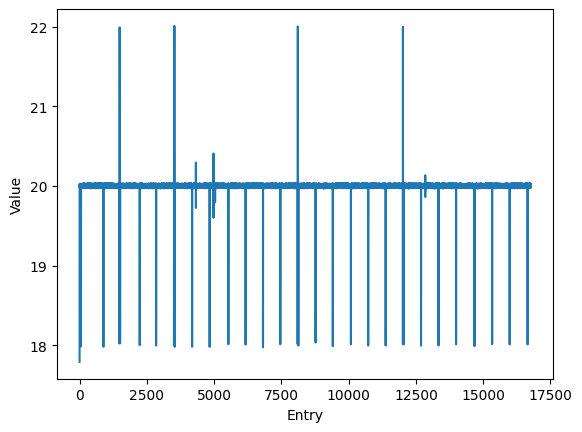

In [248]:
prev = df["timestamp"].iloc[0]

delay = []

for _, row in df.iterrows():
    diff = (row["timestamp"] - prev).total_seconds()
    delay.append(diff)

    prev = row["timestamp"]

print(df.count())

plt.plot(delay[1:len(delay)-15])

plt.xlabel("Entry")
plt.ylabel("Value")

plt.show()